# 01 · The spine — DGPs, estimators & the Monte-Carlo harness (built by hand, then promoted)

The **architectural spine** of Lyra (LYRA §3–§5) and **NB 01** of the curriculum (`ROADMAP.md`). We
build everything **from scratch** so you see every mechanic, *then* (§6) we **promote** the raw code
into `lyra/` modules — the worked example of our notebook→`.py` workflow. We implement, with the
libraries directly:

1. a **DGP** we author (so we *know* the truth) — Level 0 (iid) then Level 1 (covariates → potential
   outcomes, a CATE surface, and a **confounding knob**);
2. three **estimators** by hand — difference-in-means, OLS adjustment, and **AIPW** (cross-fitted,
   doubly-robust) — writing out the score/influence function;
3. the **Monte-Carlo harness** — the raw loop `sample → estimate → compare-to-truth` that reports
   bias / coverage / power, and becomes the *promotion gate* for every future estimator;
4. the **robustness grid** — deliberately break assumptions and watch **OLS bias while AIPW survives**;
5. then **§6 promote** to `lyra/{protocols,dgp,estimators,harness}.py` and verify parity.

Sections 1–5 import *no* helpers of ours — all raw. **Learn first, productionize second.**

In [14]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.model_selection import KFold

import nbtools; nbtools.set_style()
from nbtools import BLUE, GREEN, PINK, ORANGE, GRAY
DIFF, OLS, AIPW = PINK, ORANGE, GREEN     # estimator colours

## 1. The idea — two mirror-image contracts, closed by a loop

Estimators **guess** the effect from observable data; a DGP **knows** the truth. Their symmetry is
the whole architecture:

$$\textsf{sim} \;\to\; \textsf{assign} \;\to\; \textsf{estimate} \;\to\;
  \textsf{compare to truth} \;\to\; \textsf{coverage / bias / power}.$$

We don't need classes yet — a **DGP is a function** `sample(n, seed) -> DataFrame` plus a known true
ATE, and an **estimator is a function** `estimate(df) -> (point, ci)`. Build the loop once and every
method we add later gets a *certified: yes/no* badge for free.

## 2. Author a DGP (so we know the truth)

### Level 0 — iid, randomized, constant effect
The simplest world: $Y = \mu + \tau\,T + \varepsilon$, with $T\sim\text{Bernoulli}(\tfrac12)$. The
**potential outcomes** are $Y(0)=\mu+\varepsilon$ and $Y(1)=\mu+\tau+\varepsilon$; the **ATE**
$\tau=\mathbb E[Y(1)-Y(0)]$ is exactly $\tau$ — *we set it*. In the example below we use
$$\mu=10,\quad \sigma=5,\quad \boxed{\tau = 2},$$
so the true effect we'll grade every estimator against is **2**.

In [15]:
def simulate_l0(n, ate=2.0, mu=10.0, sigma=5.0, seed=0):
    rng = np.random.default_rng(seed)
    treat = (rng.random(n) < 0.5).astype(int)
    y = mu + ate * treat + rng.normal(0, sigma, n)
    return pd.DataFrame({"treat": treat, "y": y})

d0 = simulate_l0(2000, ate=2.0, seed=1)
print("L0 sample:", len(d0), "rows | naive diff-in-means =",
      round(d0[d0.treat == 1].y.mean() - d0[d0.treat == 0].y.mean(), 3), " (true ATE = 2.0)")
d0.head(3)

L0 sample: 2000 rows | naive diff-in-means = 2.061  (true ATE = 2.0)


,treat,y
0,0,5.005127
1,0,10.705426
2,1,19.876913
3,0,9.818609
4,1,8.931921


### Level 1 — covariates → potential outcomes, with a confounding knob

Now each unit has covariates $X\in\mathbb R^d$ (age, history, segment…). We author **both** potential
outcomes; the covariates $X$ drive **both** through a shared **baseline** $b(X)$, and treatment just
adds the effect on top:
$$Y(0)=b(X)+\varepsilon,\qquad Y(1)=\underbrace{b(X)}_{\text{same }X\text{-driven baseline}}+\;\tau(X)+\varepsilon.$$
So $X$ affects the *level* of the outcome in either arm; the **treatment effect is the gap**
$Y(1)-Y(0)=\tau(X)$ (here constant, $\tau(X)\equiv\tau$, so $\text{ATE}=\tau$). Writing it as
"$Y(1)=Y(0)+\tau$" is the same statement — $Y(1)$ keeps $b(X)$ and $\varepsilon$ from $Y(0)$ and just
shifts up by $\tau$. (In code: `y0 = b(X) + noise`, then the treated observe `y0 + tau`.) The baseline
$b(X)$ is linear or **nonlinear**.

**Why a propensity? (the jump from covariates to $e(X)$ — Wager ch.1–2).** Outside a clean A/B test,
*who gets treated isn't random* — it depends on the covariates. The **propensity**
$$e(x)=P(T=1\mid X=x)$$
*is* that assignment mechanism: the probability a unit with covariates $x$ ends up treated. The whole
theory of observational causal inference rests on two assumptions about it:

- **Unconfoundedness** (selection on observables, Rosenbaum–Rubin 1983):
  $\{Y(0),Y(1)\}\perp\!\!\!\perp T \mid X$ — once we condition on $X$, treatment is *as good as random*
  (no hidden confounders). Remarkably, conditioning on the scalar $e(X)$ alone suffices —
  $\{Y(0),Y(1)\}\perp\!\!\!\perp T \mid e(X)$ — so the propensity is a **balancing score**: matching/weighting
  on $e(X)$ recreates a randomized comparison.
- **Overlap / positivity:** $0<e(x)<1$ for all $x$ — every kind of unit could in principle receive
  either arm, or there's nothing to compare. (Estimators that divide by $e$ blow up as $e\to0$.)

Our **confounding knob** $\kappa$ dials the propensity from a clean experiment to a nasty observational
study:
$$e(X)=\begin{cases}\tfrac12 & \kappa=0\ \text{(randomized — unconfounded by design, }e\text{ known)}\\[2pt]
  \mathrm{logit}^{-1}\!\big(\kappa\cdot c(X)\big) & \kappa>0\ \text{(observational — }e\text{ depends on }X)\end{cases}$$
When $\kappa>0$ the *same* $X$ drives both the propensity **and** the baseline $b(X)$ — so treated and
control groups differ in $X$ (confounding), and a naive comparison confuses the treatment effect with
$b(X)$. **Because we authored it, the true ATE stays known no matter how nasty $\kappa$ gets** — which
is exactly what lets the harness *grade* each estimator.

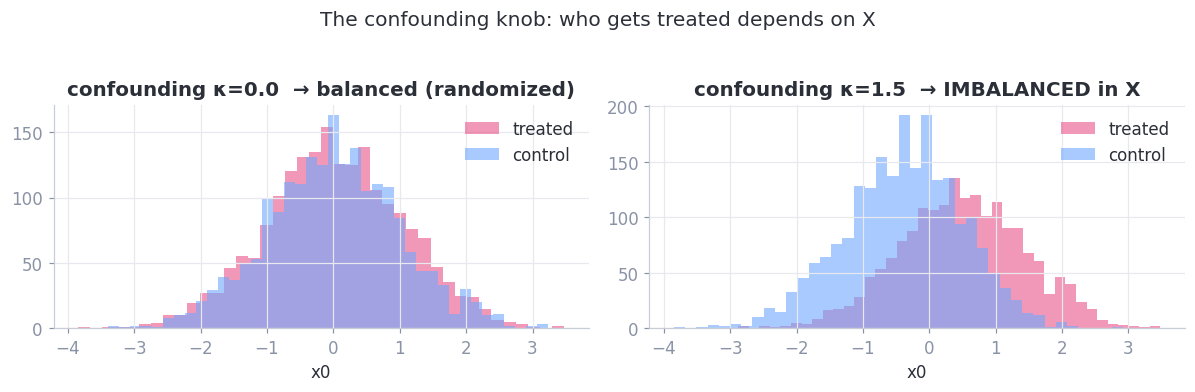

In [16]:
def baseline(X, nonlinear):
    if nonlinear:                      # genuinely curved in X — a linear model can't match it
        return 2.0 * np.sin(1.5 * X[:, 0]) + X[:, 1] ** 2 + 1.5 * X[:, 0] * X[:, 1]
    return 1.2 * X[:, 0] - 0.8 * X[:, 1] + 0.5 * X[:, 2]

def simulate_l1(n, ate=2.0, confounding=0.0, nonlinear=False, d=5, sigma=1.0, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, (n, d))
    b = baseline(X, nonlinear)
    c = X[:, 0] + (X[:, 1] ** 2 - 1.0)                      # confounder signal (mean ~0)
    e = np.full(n, 0.5) if confounding == 0 else 1 / (1 + np.exp(-confounding * c))
    treat = (rng.random(n) < e).astype(int)
    y0 = b + rng.normal(0, sigma, n)                        # potential outcome under control
    y = y0 + ate * treat                                   # observed = Y(0) or Y(0)+ate
    df = pd.DataFrame(X, columns=[f"x{j}" for j in range(d)])
    df.insert(0, "y", y); df.insert(0, "treat", treat)
    return df

# show the confounding: treated vs control differ in X when kappa>0
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for k, a in zip([0.0, 1.5], ax):
    dd = simulate_l1(4000, confounding=k, nonlinear=True, seed=2)
    a.hist(dd[dd.treat == 1].x0, bins=40, alpha=.6, color=PINK, label="treated")
    a.hist(dd[dd.treat == 0].x0, bins=40, alpha=.6, color=BLUE, label="control")
    a.set_title(f"confounding κ={k}  → {'balanced (randomized)' if k==0 else 'IMBALANCED in X'}")
    a.set_xlabel("x0"); a.legend()
fig.suptitle("The confounding knob: who gets treated depends on X", y=1.04)
plt.tight_layout(); plt.show()

## 3. Three estimators, by hand

### 3a. Difference-in-means — $\hat\tau = \bar y_1 - \bar y_0$
Unbiased *only* under randomization (then $T\perp X$, so the groups are comparable). Welch CI for
unequal variances.

In [17]:
def est_diff(df):
    t = df.loc[df.treat == 1, "y"].to_numpy(); c = df.loc[df.treat == 0, "y"].to_numpy()
    point = t.mean() - c.mean()
    se = np.sqrt(t.var(ddof=1) / t.size + c.var(ddof=1) / c.size)        # Welch SE
    dof = (se**4) / ((t.var(ddof=1)/t.size)**2/(t.size-1) + (c.var(ddof=1)/c.size)**2/(c.size-1))
    h = stats.t.ppf(0.975, dof) * se
    return point, (point - h, point + h), se

### 3b. OLS adjustment — regress $y$ on treatment **and the covariates**
$y_i=\alpha+\tau\,T_i + X_i'\beta + u_i$. The linear $X'\beta$ soaks up *linear* confounding, so OLS
is unbiased when $b(X)$ is linear — but it **cannot** match a curved $b(X)$, leaving residual
confounding. We read the coefficient on `treat` with a heteroskedasticity-robust (HC1) SE.

In [18]:
def est_ols(df):
    xcols = [c for c in df.columns if c.startswith("x")]
    Xd = sm.add_constant(df[["treat", *xcols]].to_numpy(float))
    m = sm.OLS(df.y.to_numpy(float), Xd).fit(cov_type="HC1")
    b, se = m.params[1], m.bse[1]                                        # 0=const, 1=treat
    return b, (b - 1.96 * se, b + 1.96 * se), se

### 3c. AIPW — doubly-robust, cross-fitted (the one that survives)
Following Wager's notation: the **response surfaces** $\mu_{(w)}(x)=\mathbb E[Y\mid X=x,\,T=w]$ and the
**propensity** $e(x)$. AIPW augments the regression imputation with an IPW correction on its residuals.
The per-unit **score** $\Gamma_i$ (Wager's notation) is
$$\Gamma_i=\underbrace{\hat\mu_{(1)}(X_i)-\hat\mu_{(0)}(X_i)}_{\text{regression imputation}}
  +\underbrace{\frac{T_i\big(Y_i-\hat\mu_{(1)}(X_i)\big)}{\hat e(X_i)}
  -\frac{(1-T_i)\big(Y_i-\hat\mu_{(0)}(X_i)\big)}{1-\hat e(X_i)}}_{\text{IPW correction on the residuals}},
  \qquad \hat\tau_{\mathrm{AIPW}}=\frac1n\sum_i \Gamma_i.$$
Two reasons it's robust: **double robustness** — consistent if *either* $\hat\mu_{(w)}$ **or** $\hat e$
is right — and **Neyman orthogonality** — first-order errors in the nuisances cancel. We fit the
nuisances with flexible ML (gradient boosting) so they can match the *nonlinear* baseline, and
**cross-fit** (fit on the other folds, predict out-of-fold) so a fit can't overfit its own residual.
The SE is the sample sd of the scores, $\widehat{\mathrm{se}}=\mathrm{sd}(\Gamma)/\sqrt n$.

> **On efficiency (the nuance you half-remembered).** It's **IPW** that Wager calls "unbiased but
> *inefficient*"; **AIPW is the *efficient* one** — asymptotically it attains the semiparametric
> efficiency bound $V^{*}$ (the smallest variance any estimator can have here; Wager Thm 3.4), and with
> a *known* propensity (Cor 3.3) it does so with *any* consistent $\hat\mu$. The honest finite-sample
> caveats: under **poor overlap** ($\hat e$ near 0/1) the IPW correction term inflates variance, and
> under **randomization** ($e$ known $=\tfrac12$) the simple regression-adjusted estimator is *already*
> efficient, so AIPW buys little there. AIPW earns its keep exactly in our hard case: confounded +
> nonlinear, where regression alone is biased.

In [19]:
def est_aipw(df, n_splits=3, clip=0.02, seed=0):
    xcols = [c for c in df.columns if c.startswith("x")]
    X = df[xcols].to_numpy(float); y = df.y.to_numpy(float); t = df.treat.to_numpy(int)
    n = len(df); mu1 = np.zeros(n); mu0 = np.zeros(n); e = np.full(n, 0.5)
    for tr, te in KFold(n_splits, shuffle=True, random_state=seed).split(X):
        for arm, mu in ((1, mu1), (0, mu0)):                            # outcome model per arm
            sel = tr[t[tr] == arm]
            g = HistGradientBoostingRegressor(max_depth=3, max_iter=100, learning_rate=0.1)
            g.fit(X[sel], y[sel]); mu[te] = g.predict(X[te])
        if 0 < t[tr].mean() < 1:                                        # propensity model
            cl = HistGradientBoostingClassifier(max_depth=3, max_iter=100, learning_rate=0.1)
            cl.fit(X[tr], t[tr]); e[te] = cl.predict_proba(X[te])[:, 1]
    e = np.clip(e, clip, 1 - clip)                                      # overlap trimming
    psi = mu1 - mu0 + t / e * (y - mu1) - (1 - t) / (1 - e) * (y - mu0)
    point = psi.mean(); se = psi.std(ddof=1) / np.sqrt(n)
    return point, (point - 1.96 * se, point + 1.96 * se), se

**One run, confounded + nonlinear world** — watch the three estimators diverge from the truth (2.0):

In [20]:
dC = simulate_l1(4000, ate=2.0, confounding=1.5, nonlinear=True, seed=3)
for name, fn, col in [("diff", est_diff, DIFF), ("ols ", est_ols, OLS), ("aipw", lambda d: est_aipw(d, seed=3), AIPW)]:
    p, (lo, hi), se = fn(dC)
    print(f"  {name}: {p:+.3f}  CI [{lo:+.3f}, {hi:+.3f}]  (bias {p-2.0:+.3f})")

  diff: +4.070  CI [+3.916, +4.224]  (bias +2.070)
  ols : +3.438  CI [+3.277, +3.598]  (bias +1.438)
  aipw: +2.186  CI [+1.933, +2.439]  (bias +0.186)


## 4. The Monte-Carlo harness — the raw loop

A single estimate is one draw; to *certify* an estimator we repeat the experiment $R$ times and look
at the **sampling behaviour**: bias (is it centred on truth?), **coverage** (do the 95% CIs contain
truth 95% of the time?), and the **reject rate** (= type-I error if the truth is 0, = power if not).
This loop is the platform's power engine *and* the gate a method must pass to be promoted.

In [21]:
def run_harness(estimate_fn, simulate_fn, R=200, n=2000, alpha=0.05, **dgp_kw):
    truth = dgp_kw.get("ate", 0.0)
    pts, cover, rej = [], [], []
    for r in range(R):
        df = simulate_fn(n, seed=1000 + r, **dgp_kw)
        p, (lo, hi), se = estimate_fn(df)
        pts.append(p); cover.append(lo <= truth <= hi); rej.append(not (lo <= 0 <= hi))
    pts = np.array(pts)
    return {"bias": pts.mean() - truth, "rmse": np.sqrt(((pts - truth) ** 2).mean()),
            "coverage": np.mean(cover), "reject_rate": np.mean(rej), "points": pts,
            "label": "type_I" if abs(truth) < 1e-9 else "power"}

# sanity on the easy world: diff-in-means should be unbiased with ~95% coverage and ~5% type-I
h0 = run_harness(est_diff, simulate_l0, R=400, n=1500, ate=0.0)
h1 = run_harness(est_diff, simulate_l0, R=400, n=1500, ate=2.0)
print("L0, diff, under H0 (ate=0):", {k: round(h0[k], 3) for k in ("bias", "coverage", "reject_rate")})
print("L0, diff, under H1 (ate=2):", {k: round(h1[k], 3) for k in ("bias", "coverage", "reject_rate")})

L0, diff, under H0 (ate=0): {'bias': 0.004, 'coverage': 0.95, 'reject_rate': 0.05}
L0, diff, under H1 (ate=2): {'bias': 0.004, 'coverage': 0.95, 'reject_rate': 1.0}


**Visualise the sampling distribution.** Each Monte-Carlo draw gives one $\hat\tau$; over the 400
draws those estimates form a distribution. A *correct* estimator's distribution is **centred on the
truth** (unbiased) and roughly Normal — and the 95% CIs miss it only ~5% of the time. Here it is for
diff-in-means on the easy (randomized) world, with the true effect marked:

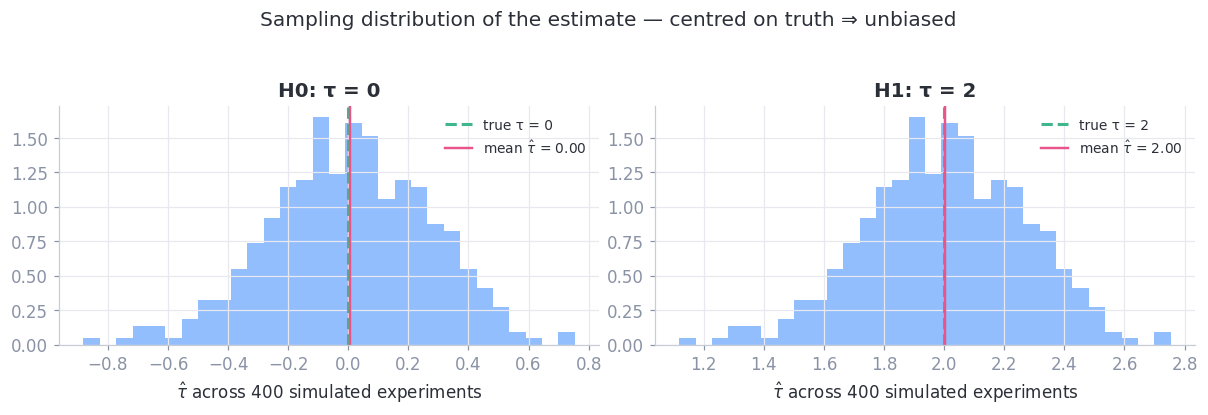

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for a, h, truth, lab in [(ax[0], h0, 0.0, "H0: τ = 0"), (ax[1], h1, 2.0, "H1: τ = 2")]:
    a.hist(h["points"], bins=30, color=BLUE, alpha=0.75, density=True)
    a.axvline(truth, color=GREEN, ls="--", lw=2, label=f"true τ = {truth:.0f}")
    a.axvline(h["points"].mean(), color=PINK, lw=1.6, label=f"mean $\\hat\\tau$ = {h['points'].mean():.2f}")
    a.set_title(lab); a.set_xlabel(r"$\hat\tau$ across 400 simulated experiments"); a.legend(fontsize=9)
fig.suptitle("Sampling distribution of the estimate — centred on truth ⇒ unbiased", y=1.04)
plt.tight_layout(); plt.show()

Both are centred on the truth (unbiased), bell-shaped, and the spread *is* the standard error. This
is the **resampling / many-draws** idea you already use with the bootstrap — except here, because we
*authored* the DGP, each draw is a fresh genuine experiment, not a resample of one dataset, so we can
read off **bias** and **coverage** directly. Coverage ≈ 0.95 and type-I ≈ 0.05 → diff-in-means is
*certified* on the world where its assumption (randomization) holds.

### Power / MDE falls out of the same loop

**What a power curve is.** We re-run the harness at several *true* effect sizes $\tau$ and, for each,
record the **reject rate** = the fraction of the simulated experiments whose 95% CI excludes 0 (i.e.
would call the result "significant"). Reading it:

- at $\tau=0$ (no real effect) the reject rate is the **type-I error** — it should sit at $\alpha=5\%$
  (the pink line): we falsely "find" an effect 5% of the time, by design;
- at $\tau>0$ the reject rate is the **power** — the chance we *detect* a real effect of that size;
- the curve climbs from 5% toward 100% as the true effect grows (bigger effects are easier to catch).

The **MDE** (minimum detectable effect) is just where the curve crosses **80% power** (dashed line):
the smallest effect this design ($n$, variance) can reliably detect. Want a smaller MDE? increase $n$,
cut variance (CUPED, NB04), or accept lower power. Sizing a study is *not* a separate formula — it's
this same harness run under the alternative, which is the **only** honest way to size designs with no
closed form (switchback, clustered).

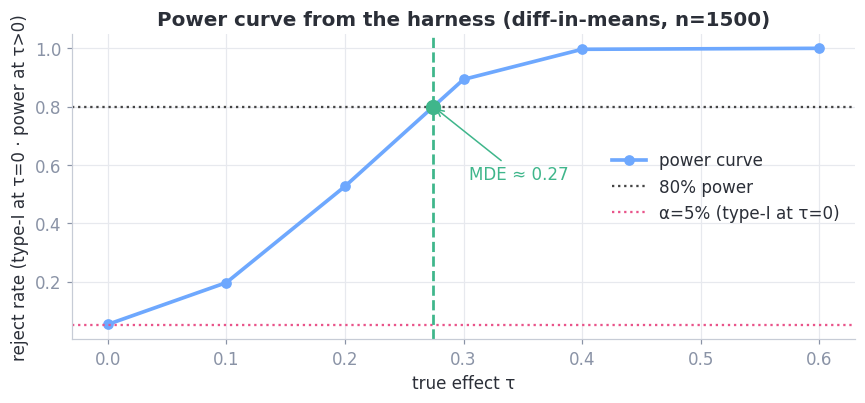

In [23]:
effects = [0.0, 0.1, 0.2, 0.3, 0.4, 0.6]
pw = [run_harness(est_diff, simulate_l1, R=300, n=1500, ate=tau, confounding=0.0)["reject_rate"]
      for tau in effects]
mde = np.interp(0.8, pw, effects)                                  # effect where power hits 80%
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(effects, pw, "-o", color=BLUE, lw=2.4, label="power curve")
ax.axhline(0.8, color="#444", ls=":", label="80% power"); ax.axhline(0.05, color=PINK, ls=":", label="α=5% (type-I at τ=0)")
ax.axvline(mde, color=GREEN, ls="--", lw=1.8); ax.plot(mde, 0.8, "o", color=GREEN, ms=9)
ax.annotate(f"MDE ≈ {mde:.2f}", (mde, 0.8), (mde + 0.03, 0.55), color=GREEN,
            arrowprops=dict(arrowstyle="->", color=GREEN))
ax.set_xlabel("true effect τ"); ax.set_ylabel("reject rate (type-I at τ=0 · power at τ>0)")
ax.set_title("Power curve from the harness (diff-in-means, n=1500)"); ax.legend(loc="center right")
plt.tight_layout(); plt.show()

## 5. The robustness grid — break assumptions, see who survives

The senior move (LYRA §6): if the DGP matches an estimator's assumptions it looks perfect and proves
nothing — you graded the exam you wrote. So we deliberately **violate** assumptions across four worlds
and chart bias + CI coverage for each estimator. The headline cell is **confounded + nonlinear**.

In [11]:
scenarios = {
    "randomized + linear":    dict(confounding=0.0, nonlinear=False),
    "randomized + nonlinear": dict(confounding=0.0, nonlinear=True),
    "confounded + linear":    dict(confounding=1.2, nonlinear=False),
    "confounded + nonlinear": dict(confounding=1.5, nonlinear=True),
}
ests = {"diff": est_diff, "ols": est_ols, "aipw": lambda d: est_aipw(d, seed=7)}
bias = pd.DataFrame(index=scenarios, columns=ests, dtype=float)
cov = pd.DataFrame(index=scenarios, columns=ests, dtype=float)
pts_store = {}                                          # keep the per-draw estimates for the visual
for scen, kw in scenarios.items():
    for en, fn in ests.items():
        rep = run_harness(fn, simulate_l1, R=40, n=1500, ate=2.0, **kw)
        bias.loc[scen, en] = rep["bias"]; cov.loc[scen, en] = rep["coverage"]
        pts_store[(scen, en)] = rep["points"]
print("BIAS (truth ATE = 2.0):"); print(bias.round(3).to_string())
print("\nCI COVERAGE (target 0.95):"); print(cov.round(2).to_string())

BIAS (truth ATE = 2.0):
                         diff    ols   aipw
randomized + linear    -0.019  0.000 -0.006
randomized + nonlinear -0.025 -0.011  0.004
confounded + linear     0.922  0.001  0.000
confounded + nonlinear  2.132  1.573  0.131

CI COVERAGE (target 0.95):
                        diff   ols  aipw
randomized + linear     0.98  0.98  0.90
randomized + nonlinear  0.98  0.95  0.98
confounded + linear     0.00  1.00  1.00
confounded + nonlinear  0.00  0.00  0.90


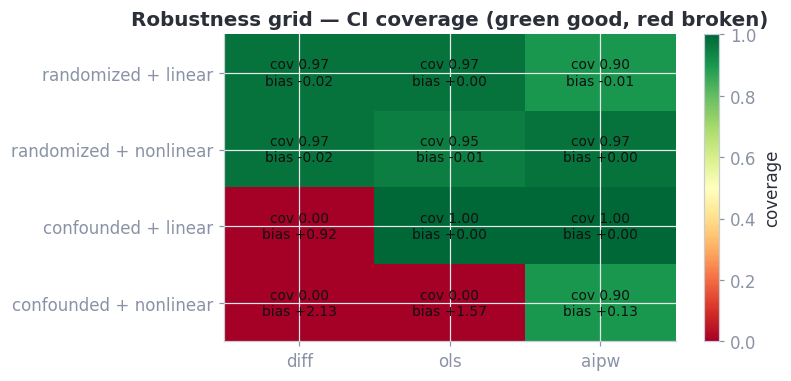

In [12]:
# the robustness grid as a heatmap, coloured by CI coverage (green=good, red=broken)
fig, ax = plt.subplots(figsize=(7.4, 3.6))
im = ax.imshow(cov.to_numpy(float), cmap="RdYlGn", vmin=0.0, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(ests))); ax.set_xticklabels(ests.keys())
ax.set_yticks(range(len(scenarios))); ax.set_yticklabels(scenarios.keys())
for i in range(len(scenarios)):
    for j in range(len(ests)):
        ax.text(j, i, f"cov {cov.iloc[i,j]:.2f}\nbias {bias.iloc[i,j]:+.2f}",
                ha="center", va="center", fontsize=9, color="#111")
ax.set_title("Robustness grid — CI coverage (green good, red broken)")
fig.colorbar(im, ax=ax, label="coverage"); plt.tight_layout(); plt.show()

**See the bias as distributions.** The heatmap colours coverage; here are the *sampling distributions*
on the hardest world (**confounded + nonlinear**) — the same 40 estimates per method that produced the
bottom row. A method is good if its cloud sits on the green truth line:

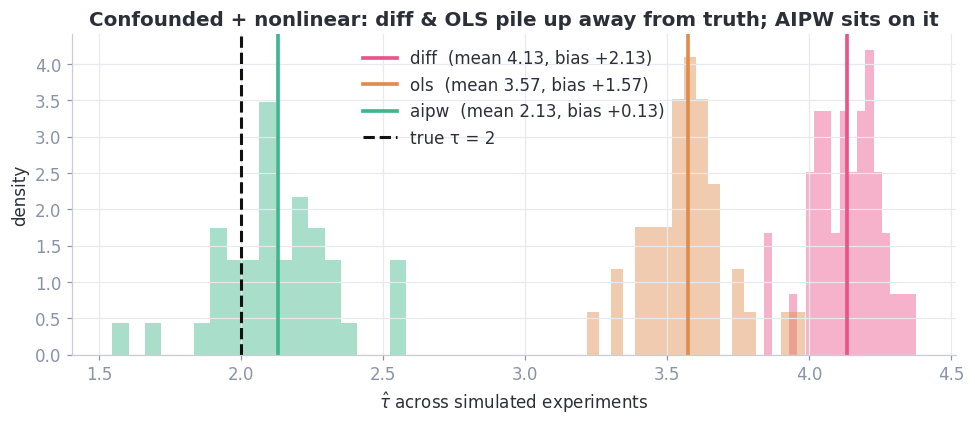

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
for en, col in [("diff", DIFF), ("ols", OLS), ("aipw", AIPW)]:
    p = pts_store[("confounded + nonlinear", en)]
    ax.hist(p, bins=18, density=True, alpha=0.45, color=col)
    ax.axvline(p.mean(), color=col, lw=2.4, label=f"{en}  (mean {p.mean():.2f}, bias {p.mean()-2:+.2f})")
ax.axvline(2.0, color="#111", ls="--", lw=2, label="true τ = 2")
ax.set_xlabel(r"$\hat\tau$ across simulated experiments"); ax.set_ylabel("density")
ax.set_title("Confounded + nonlinear: diff & OLS pile up away from truth; AIPW sits on it"); ax.legend()
plt.tight_layout(); plt.show()

Read the bottom row — **confounded + nonlinear**:
- **diff** biases hard (ignores $X$ entirely) and its CI almost never covers truth.
- **ols** also biases — the *linear* adjustment can't match the curved $b(X)$, so residual confounding
  leaks into the treatment coefficient. *This is the demonstrated "OLS biases" point.*
- **aipw** stays ≈ unbiased with ≈ 0.95 coverage — flexible nuisances + double robustness absorb the
  nonlinear confounding. *This is "AIPW survives."*

(Top rows are the sanity checks: under randomization all three agree, because $T\perp X$.)

*Efficiency caveat (per §3c):* in those randomized top rows AIPW is **no tighter** than the simpler
estimators — flexibility isn't free, and under known $e$ regression adjustment is already efficient.
AIPW earns its keep precisely in the bottom-row regime, where the others are biased.

## 6. Promote — lift the raw code into `lyra/` (the worked example of the workflow)

We now *understand* every line, so we promote (LYRA §10). The raw functions above are lifted, with no
logic change, into reusable modules behind the two **contracts**:

- `lyra/protocols.py` — `EstimatorResult`, `Estimator`, `DGP`, `GroundTruth`;
- `lyra/dgp.py` — `DGPLevel0`, `DGPLevel1` (the fidelity ladder);
- `lyra/estimators.py` — `DiffInMeans`, `OLSAdjust`, `AIPW`;
- `lyra/harness.py` — `harness`, `robustness_grid`, `power_curve` (the certifier).

**The promotion gate is parity:** the promoted code must reproduce what we built by hand. We check it
by running the *same harness* through the new modules and comparing to the raw result.

In [14]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))      # repo root on the path
from lyra.dgp import DGPLevel1
from lyra.estimators import DiffInMeans, OLSAdjust, AIPW
from lyra.harness import harness, robustness_grid

# raw (the functions defined in this notebook) vs promoted (the lyra classes), same world & seeds
raw = run_harness(lambda d: est_aipw(d, seed=7), simulate_l1, R=40, n=1500, ate=2.0,
                  confounding=1.5, nonlinear=True)
pro = harness(AIPW(seed=7), DGPLevel1(confounding=1.5, nonlinear=True, ate=2.0), R=40, n=1500, seed0=1000)
print("AIPW on confounded+nonlinear  (truth 2.0):")
print(f"  raw      bias {raw['bias']:+.3f}  coverage {raw['coverage']:.2f}")
print(f"  promoted bias {pro['bias']:+.3f}  coverage {pro['coverage']:.2f}")
print(f"  parity: bias delta {abs(raw['bias']-pro['bias']):.4f}  (~0 => promotion is faithful)")

AIPW on confounded+nonlinear  (truth 2.0):
  raw      bias +0.131  coverage 0.90
  promoted bias +0.131  coverage 0.90
  parity: bias delta 0.0000  (~0 => promotion is faithful)


In [15]:
# the promoted modules now reproduce the whole robustness grid in two lines — the reusable certifier
scen = {
    "rand+linear":    DGPLevel1(confounding=0.0, nonlinear=False),
    "rand+nonlinear": DGPLevel1(confounding=0.0, nonlinear=True),
    "conf+linear":    DGPLevel1(confounding=1.2, nonlinear=False),
    "conf+nonlinear": DGPLevel1(confounding=1.5, nonlinear=True),
}
grid = robustness_grid([DiffInMeans(), OLSAdjust(), AIPW(seed=7)], scen, R=30, n=1500)
print(grid.pivot(index="scenario", columns="estimator", values="coverage").round(2).to_string())

estimator       aipw  diff   ols
scenario                        
conf+linear     1.00  0.00  1.00
conf+nonlinear  0.97  0.00  0.00
rand+linear     0.90  0.97  1.00
rand+nonlinear  0.97  0.97  0.97


✅ **Promoted.** `lyra/` now holds the spine, and `harness(estimator, dgp)` will **certify every
future method** (CATE learners, switchback, DiD, …) against a known truth — exactly the gate that
makes "in production" mean something. Next notebook (per `ROADMAP.md`): **NB 02 — metrics**.